In [7]:
import pandas as pd
import numpy as np
%pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

In [10]:
house = pd.read_csv('data/housing_prices_data.csv') # Importing the dataset
house

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [12]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 40.5+ KB


In [13]:
house.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [14]:
'''
The next step will be to preprocess this dataset. Here, two processes will be used:
1. All the binary 'yes'/'no' columns will be mapped to integer values of 1/0 to allow them to be used as features.
2. The one categorical column with multiple unique values, 'furnishingstatus', shall be one-hot encoded using pd.get_dummies()
'''

"\nThe next step will be to preprocess this dataset. Here, two processes will be used:\n1. All the binary 'yes'/'no' columns will be mapped to integer values of 1/0 to allow them to be used as features.\n2. The one categorical column with multiple unique values, 'furnishingstatus', shall be one-hot encoded using pd.get_dummies()\n"

In [15]:
bin_col = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea'] 

# Parsing the binary columns and mapping them one at a time.
for col in bin_col:
    house[col] = house[col].map({'yes':1, 'no':0})

# One-hot encoding the 'furnishingstatus' column
house = pd.get_dummies(house, columns = ['furnishingstatus'], drop_first=True, prefix='fs', dtype = int)
house

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,fs_semi-furnished,fs_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [17]:
X = house.drop('price', axis=1)
Y = house['price']

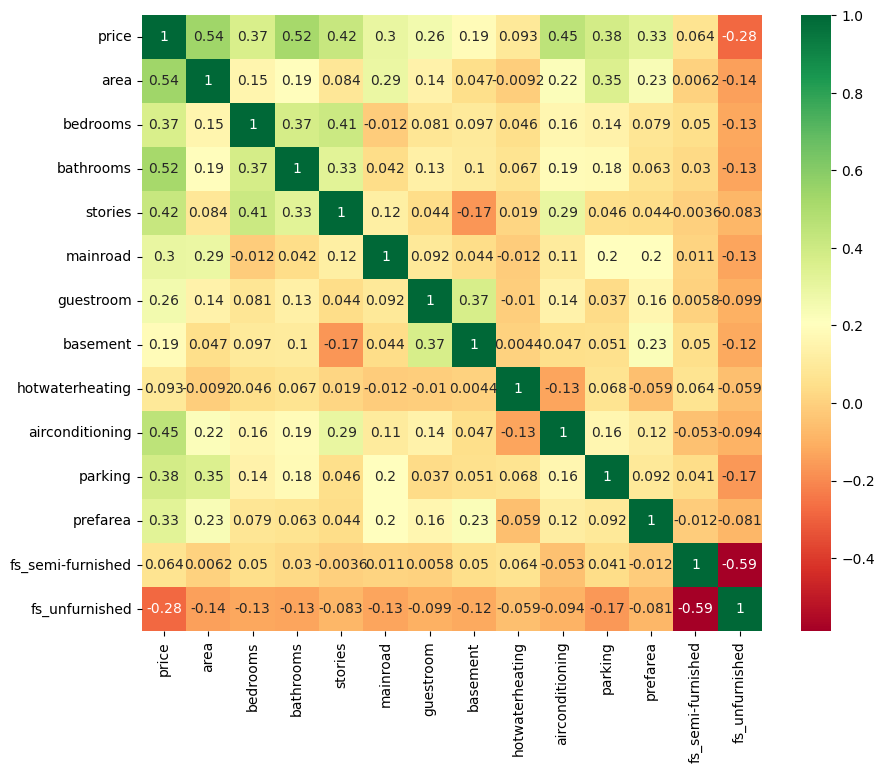

In [19]:
house_corr = house.corr() # Creating the correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(house_corr, annot=True, cmap='RdYlGn')
plt.show()

In [22]:
pf = PolynomialFeatures(degree = 2, include_bias = False)
X_pf = pf.fit_transform(X)

In [26]:
scores = pd.DataFrame(columns=['Model','R2_Score','RMSE'])

In [28]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, 
                                          test_size = 0.3, 
                                          random_state = 51)

X_pf_train, X_pf_test, Y_train, Y_test = train_test_split(X_pf, Y, 
                                                      test_size = 0.3, 
                                                      random_state = 51)

In [30]:
LR = LinearRegression() # Initializing regression object

# Fitting and predicting on original dataset
LR = LR.fit(X_train, Y_train)
Y_pred = LR.predict(X_test)
score = r2_score(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
scores.loc[len(scores)] = ['LR', score, rmse]

# Fitting and predicting on dataset with polynomial features added
LR = LR.fit(X_pf_train, Y_train)
Y_pred = LR.predict(X_pf_test)
score = r2_score(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
scores.loc[len(scores)] = ['LR with PF', score, rmse]

scores

,Model,R2_Score,RMSE
0,LR,0.674046,9.753212e+05
1,LR with PF,0.181573,1.545467e+06


In [34]:
SS = StandardScaler() # Initializing scaler object

# Fitting and predicting on the scaled dataset
X_train_ss = SS.fit_transform(X_train)
X_test_ss = SS.transform(X_test)
LR.fit(X_train_ss, Y_train)
Y_pred = LR.predict(X_test_ss)

score = r2_score(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
scores.loc[len(scores)] = ['LR with scaling', score, rmse]

scores

,Model,R2_Score,RMSE
0,LR,0.674046,9.753212e+05
1,LR with PF,0.181573,1.545467e+06
2,LR with scaling,0.674046,9.753212e+05


In [36]:
MM = MinMaxScaler() # Initializing scaler objects
MA = MaxAbsScaler()

# Scaling with MinMaxScaler()
X_train_mm = MM.fit_transform(X_train)
X_test_mm = MM.transform(X_test)
LR.fit(X_train_mm, Y_train)
Y_pred = LR.predict(X_test_mm)

score = r2_score(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
scores.loc[len(scores)] = ['LR with scaled (MM)', score, rmse]

# Scaling with MaxAbsScaler()
X_train_ma = MA.fit_transform(X_train)
X_test_ma = MA.transform(X_test)
LR.fit(X_train_ma, Y_train)
Y_pred = LR.predict(X_test_ma)

score = r2_score(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
scores.loc[len(scores)] = ['LR with scaling (MA)', score, rmse]

scores

,Model,R2_Score,RMSE
0,LR,0.674046,9.753212e+05
1,LR with PF,0.181573,1.545467e+06
2,LR with scaling,0.674046,9.753212e+05
3,LR with scaled (MM),0.674046,9.753212e+05
4,LR with scaling (MA),0.674046,9.753212e+05


In [39]:
kf = KFold(n_splits = 4, shuffle = True, random_state = 51) # Initializing KFold object with defined parameters

r2_scores = [] # Creating empty lists to store scoring metrics for every fold
rmse_scores = []
for train_id, val_id in kf.split(X):
    X_train, X_val, Y_train, Y_val = (X.iloc[train_id, :], 
                                      X.iloc[val_id, :], 
                                      Y[train_id], 
                                      Y[val_id])

    X_train_ss = SS.fit_transform(X_train)
    X_val_ss = SS.transform(X_val)
    LR.fit(X_train_ss, Y_train)
    Y_pred = LR.predict(X_val_ss)
    
    score = r2_score(Y_val, Y_pred)
    r2_scores.append(score)
    rmse = np.sqrt(mean_squared_error(Y_val, Y_pred))
    rmse_scores.append(rmse)

print("R2 Scores: ", r2_scores)
print("RMSEs: ", rmse_scores)
scores.loc[len(scores)] = ['LR with KFold', np.mean(r2_scores), np.mean(rmse_scores)]
scores

R2 Scores:  [0.6650891599021809, 0.59996608020805, 0.6479808679306458, 0.681744178636062]
RMSEs:  [np.float64(1001745.9155032798), np.float64(1032505.277970756), np.float64(1256387.246074472), np.float64(1100887.7186502723)]


,Model,R2_Score,RMSE
0,LR,0.674046,9.753212e+05
1,LR with PF,0.181573,1.545467e+06
2,LR with scaling,0.674046,9.753212e+05
3,LR with scaled (MM),0.674046,9.753212e+05
4,LR with scaling (MA),0.674046,9.753212e+05
5,LR with KFold,0.648695,1.097882e+06


In [44]:
ss = StandardScaler() # Initializing scaler and regression objects
lr = LinearRegression()
kf = KFold(n_splits = 4, shuffle = True, random_state = 51)

model = Pipeline([('Scaler', ss),
                  ('LinReg', lr)])

predictions = cross_val_predict(model, X, Y, cv = kf)

score = r2_score(Y, predictions)
rmse = np.sqrt(mean_squared_error(Y, predictions))
scores.loc[len(scores)] = ['LR using Pipeline', score, rmse]
scores

,Model,R2_Score,RMSE
0,LR,0.674046,9.753212e+05
1,LR with PF,0.181573,1.545467e+06
2,LR with scaling,0.674046,9.753212e+05
3,LR with scaled (MM),0.674046,9.753212e+05
4,LR with scaling (MA),0.674046,9.753212e+05
5,LR with KFold,0.648695,1.097882e+06
6,LR using Pipeline,0.652184,1.102097e+06


In [49]:
alphas = np.geomspace(1e-2, 1e6, num=9) # Creating the list of alphas
las_scores = [] # Initializing empty lists to store scoring metrics for each iteration
las_rmse = []

for alpha in alphas: # Iterating through each alpha
    lasso = Lasso(alpha = alpha, max_iter = 10000)
    model = Pipeline([('Scaler', ss),
                      ('Lasso', lasso)])
    predictions = cross_val_predict(model, X, Y, cv = kf)

    score = r2_score(Y, predictions)
    rmse = np.sqrt(mean_squared_error(Y, predictions))
    print(alpha, ' - ', score)
    las_scores.append(score)
    las_rmse.append(rmse)

scores.loc[len(scores)] = ['Lasso Pipeline', np.max(las_scores), np.max(las_rmse)]
scores

0.01  -  0.6521836764948408
0.1  -  0.6521836806182294
1.0  -  0.6521837216787016
10.0  -  0.6521841410060828
100.0  -  0.6521882639015846
1000.0  -  0.6522272028349538
10000.0  -  0.6524345478750837
100000.0  -  0.63687473911377
1000000.0  -  0.010329794491712563


,Model,R2_Score,RMSE
0,LR,0.674046,9.753212e+05
1,LR with PF,0.181573,1.545467e+06
2,LR with scaling,0.674046,9.753212e+05
3,LR with scaled (MM),0.674046,9.753212e+05
4,LR with scaling (MA),0.674046,9.753212e+05
5,LR with KFold,0.648695,1.097882e+06
6,LR using Pipeline,0.652184,1.102097e+06
7,Lasso Pipeline,0.652435,1.859046e+06


In [51]:
alphas = np.geomspace(1e-4, 1e4, num=9) # Creating the list of alphas
rid_scores = [] # Initializing empty lists to store scoring metrics for each iteration
rid_rmse = []

for alpha in alphas: # Iterating through each alpha
    ridge = Ridge(alpha = alpha, max_iter = 10000)
    model = Pipeline([('Scaler', ss),
                      ('Ridge', ridge)])
    predictions = cross_val_predict(model, X, Y, cv = kf)

    score = r2_score(Y, predictions)
    rmse = np.sqrt(mean_squared_error(Y, predictions))
    print(alpha, ' - ', score)
    rid_scores.append(score)
    rid_rmse.append(rmse)

scores.loc[len(scores)] = ['Ridge Pipeline', np.max(rid_scores), np.max(rid_rmse)]
scores

0.0001  -  0.6521836863626407
0.001  -  0.6521837792947275
0.01  -  0.6521847084681411
0.1  -  0.6521939854643704
1.0  -  0.6522852890567312
10.0  -  0.6530586992255216
100.0  -  0.651335047809309
1000.0  -  0.48842016114300435
10000.0  -  0.1111905991866382


,Model,R2_Score,RMSE
0,LR,0.674046,9.753212e+05
1,LR with PF,0.181573,1.545467e+06
2,LR with scaling,0.674046,9.753212e+05
3,LR with scaled (MM),0.674046,9.753212e+05
4,LR with scaling (MA),0.674046,9.753212e+05
5,LR with KFold,0.648695,1.097882e+06
6,LR using Pipeline,0.652184,1.102097e+06
7,Lasso Pipeline,0.652435,1.859046e+06
8,Ridge Pipeline,0.653059,1.761770e+06


In [54]:
scores

,Model,R2_Score,RMSE
0,LR,0.674046,9.753212e+05
1,LR with PF,0.181573,1.545467e+06
2,LR with scaling,0.674046,9.753212e+05
3,LR with scaled (MM),0.674046,9.753212e+05
4,LR with scaling (MA),0.674046,9.753212e+05
5,LR with KFold,0.648695,1.097882e+06
6,LR using Pipeline,0.652184,1.102097e+06
7,Lasso Pipeline,0.652435,1.859046e+06
8,Ridge Pipeline,0.653059,1.761770e+06


In [56]:
ss = StandardScaler() # Initializing scaler, regression, regularization, KFold objects
lr = LinearRegression()
lasso = Lasso(max_iter = 10000)
ridge = Ridge(max_iter = 10000)
kf = KFold(n_splits = 4, shuffle = True, random_state = 51)

alphas = np.geomspace(1e0, 1e5, num=6) # Creating list of alphas

model = Pipeline([('Scaler', ss), # Defining pipeline
                  ('Reg', lr)])

params = [{"Reg": [lr],}, # Defining list of parameters to iterate through
          {"Reg": [lasso],
           "Reg__alpha": alphas},
          {"Reg": [ridge],
           "Reg__alpha": alphas}]

grid = GridSearchCV(model, params, cv = kf, scoring = 'r2', n_jobs=-1)
grid.fit(X_pf, Y)

print("Best model : ", grid.best_estimator_)
print("Best parameters : ", grid.best_params_)
print("R-squared score : ", grid.best_score_)

/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.517e+13, tolerance: 1.491e+11
  model = cd_fast.enet_coordinate_descent(
/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.265e+13, tolerance: 1.541e+11
  model = cd_fast.enet_coordinate_descent(
/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.060e+13, tolerance: 1.292e+11
  model = cd_fast.enet_coo

Best model :  Pipeline(steps=[('Scaler', StandardScaler()),
                ('Reg', Ridge(alpha=np.float64(100.0), max_iter=10000))])
Best parameters :  {'Reg': Ridge(max_iter=10000), 'Reg__alpha': np.float64(100.0)}
R-squared score :  0.670090189504127
